In [1]:
import torch

In [2]:
import pandas as pd
import numpy as np

In [3]:
FOLD = 0
input_dir = "/scratch1/smaruj/genomic_map_transformation"

df = pd.read_csv(f"{input_dir}/df_select_fold{FOLD}.tsv", sep="\t")

df['target_chrom'] = df['chrom'].shift(-1)
df['target_start'] = df['start'].shift(-1)
df['target_end'] = df['end'].shift(-1)

# Fill last row with values from the first row
df.loc[df.index[-1], 'target_chrom'] = df.loc[df.index[0], 'chrom']
df.loc[df.index[-1], 'target_start'] = df.loc[df.index[0], 'start']
df.loc[df.index[-1], 'target_end'] = df.loc[df.index[0], 'end']

# Convert to int
df['target_start'] = df['target_start'].astype(int)
df['target_end'] = df['target_end'].astype(int)

In [4]:
df.head()

,chrom,start,end,fold,target_chrom,target_start,target_end
0,chr5,63203328,64514048,fold0,chr3,138672128,139982848
1,chr3,138672128,139982848,fold0,chr5,43542528,44853248
2,chr5,43542528,44853248,fold0,chr3,115171328,116482048
3,chr3,115171328,116482048,fold0,chr7,61700096,63010816
4,chr7,61700096,63010816,fold0,chr4,141115392,142426112


In [5]:
seq_init = torch.load("/scratch1/smaruj/genomic_map_transformation/movie/seq_0.pt")    # initial sequence
seq_final = torch.load("/scratch1/smaruj/genomic_map_transformation/movie/seq_255.pt") # final edited sequence

/tmp/SLURM_1495880/ipykernel_2184474/3804705318.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  seq_init = torch.load("/scratch1/smaruj/genomic_map_transformation/movie/

In [8]:
CTCF_PWM = "/home1/smaruj/IterativeMutagenesis/MA0139.1.meme"

In [9]:
def read_meme_pwm_as_numpy(filename):
    pwm_list = []  # List to store PWM rows
    
    with open(filename, 'r') as file:
        in_matrix_section = False
        
        for line in file:
            line = line.strip()
            
            # Check if we are reading the PWM matrix
            if line.startswith("letter-probability matrix"):
                in_matrix_section = True  # Start reading matrix data
                continue  # Skip this header line
            
            # If we are in the matrix section, process the rows
            if in_matrix_section and line:
                pwm_row = [float(value) for value in line.split()]  # Parse values
                pwm_list.append(pwm_row)  # Append to the PWM list
            
            # If we encounter a new MOTIF or the end of file, stop matrix reading
            if line.startswith("MOTIF") and in_matrix_section:
                break
    
    # Convert the list to a numpy array
    pwm_array = np.array(pwm_list)
    
    return pwm_array

In [10]:
pwm_CTCF = read_meme_pwm_as_numpy(CTCF_PWM)
pwm_CTCF_tensor = torch.from_numpy(pwm_CTCF.T).float()
motifs_dict = {"CTCF": pwm_CTCF_tensor}

In [11]:
from tangermeme.tools import fimo

In [12]:
from pyfaidx import Fasta

In [13]:
genome = Fasta("/project/fudenber_735/genomes/mm10/mm10.fa")

# Coordinates of tehe target
chrom = "chr3"
start = 138_672_128
end = 139_982_848

In [14]:
seq_target_str = genome[chrom][start:end].seq.upper()

In [15]:
def one_hot_encode(seq):
    mapping = {"A":0, "C":1, "G":2, "T":3}
    ohe = np.zeros((4, len(seq)), dtype=np.float32)
    for i, base in enumerate(seq):
        if base in mapping:
            ohe[mapping[base], i] = 1.0
    return ohe

In [16]:
seq_target = one_hot_encode(seq_target_str)

In [18]:
seq_target_tensor = torch.from_numpy(seq_target).float().unsqueeze(0)

### Original Seq

In [20]:
orig_hits = fimo.fimo(
    motifs=motifs_dict,
    sequences=seq_init,
    threshold=1e-4,
    reverse_complement=True
)[0]

In [24]:
def ctcf_hits_from_fimo(fimo_df, seq_len=1310720, bin_size=2048):
    """
    Convert FIMO motif hits into binned counts per strand.

    fimo_df: DataFrame returned by fimo.fimo
        Must contain 'start', 'end', 'strand' columns.
    seq_len: int, total sequence length
    bin_size: int, size of each bin
    """
    n_bins = seq_len // bin_size
    hits_plus = np.zeros(n_bins)
    hits_minus = np.zeros(n_bins)

    for _, row in fimo_df.iterrows():
        # 0-based index of the start position
        bin_idx = int(row['start'] // bin_size)
        if bin_idx >= n_bins:
            continue
        if row['strand'] == '+':
            hits_plus[bin_idx] += 1
        else:
            hits_minus[bin_idx] += 1

    return hits_plus, hits_minus

In [26]:
ctcf_init_plus, ctcf_init_minus = ctcf_hits_from_fimo(orig_hits)

In [28]:
import matplotlib.pyplot as plt

def plot_ctcf(ctcf_plus, ctcf_minus, title="CTCF", bin_size=2048):
    NBINS = len(ctcf_plus)
    MAX_CTCF_HITS = max(ctcf_plus.max(), ctcf_minus.max()) + 1
    x = np.arange(NBINS)
    
    plt.figure(figsize=(15, 3))
    plt.bar(x, ctcf_plus, width=1.0, color='black', alpha=0.7, label='+ strand')
    plt.bar(x, -ctcf_minus, width=1.0, color='red', alpha=0.7, label='− strand')
    plt.axhline(0, color='gray', linewidth=0.5)
    plt.xlim(0, NBINS)
    plt.ylim(-MAX_CTCF_HITS, MAX_CTCF_HITS)
    plt.xlabel(f"Bin ({bin_size} bp)")
    plt.ylabel("CTCF")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

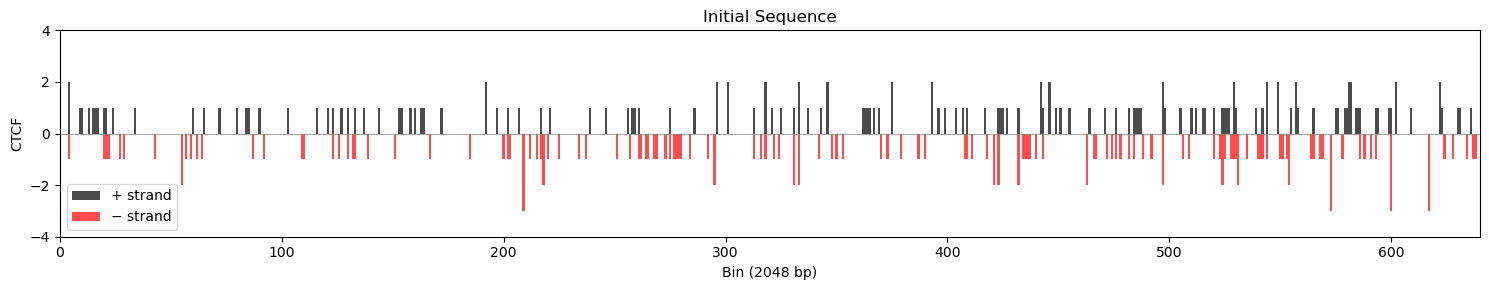

In [29]:
plot_ctcf(ctcf_init_plus, ctcf_init_minus, title="Initial Sequence")

### Final Seq

In [30]:
final_hits = fimo.fimo(
    motifs=motifs_dict,
    sequences=seq_final,
    threshold=1e-4,
    reverse_complement=True
)[0]

In [31]:
ctcf_final_plus, ctcf_final_minus = ctcf_hits_from_fimo(final_hits)

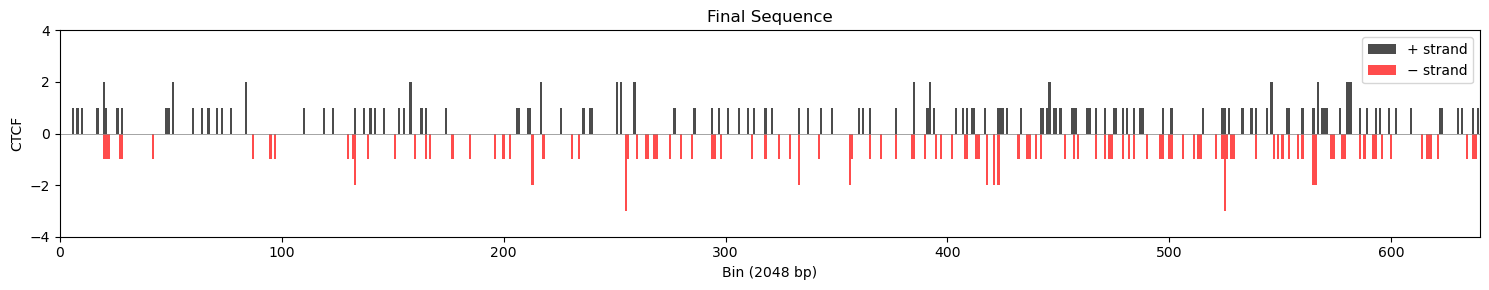

In [32]:
plot_ctcf(ctcf_final_plus, ctcf_final_minus, title="Final Sequence")

### Target Seq

In [33]:
target_hits = fimo.fimo(
    motifs=motifs_dict,
    sequences=seq_target_tensor,
    threshold=1e-4,
    reverse_complement=True
)[0]

In [34]:
ctcf_target_plus, ctcf_target_minus = ctcf_hits_from_fimo(target_hits)

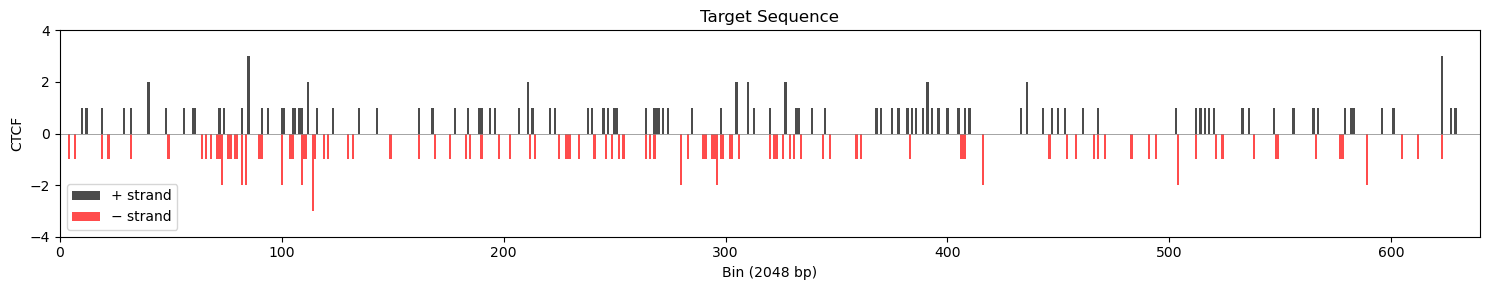

In [35]:
plot_ctcf(ctcf_target_plus, ctcf_target_minus, title="Target Sequence")